In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
cd /content/drive/MyDrive/Colab_Notebooks/

/content/drive/MyDrive/Colab_Notebooks


In [ ]:
"""
IMPORT LIBRERIE
"""
import pandas as pd
import numpy as np
import seaborn as sns

from matplotlib import pyplot as plt
plt.rcParams.update({'figure.max_open_warning': 0})

In [ ]:
"""
INIZIALIZE PARAMETERS
"""
seeding = True
N = 5 # SAMPLE TEST_DATA, scelgo numero casuale per testare il modello
check_data = True
PLOT = True

if seeding:
    import random
    random.seed(10)
    print(f'SEED: {random.random()}')

SEED: 0.5714025946899135


In [ ]:
"""
LOAD DATASET
"""

test_data = pd.read_csv('parkinsons.data', delimiter=",").sample(N).copy()
test_data.drop(columns='name', inplace=True)

pred_raw = pd.read_csv('parkinsons.data', delimiter=",").copy()

pred_data = pred_raw.drop(index=test_data.index)
pred_data.drop(columns=['name'], inplace=True)

In [ ]:
"""
ANALISI VALORI FEATURES E RICERCA DATI MANCANTI O ZERO
"""
if check_data:
    # Faccio questa cosa per tutto
    print(pred_raw.info())
    # Non ci sono dati mancanti
    print(pred_raw.describe())
    # Non ci sono zeri (se anche fosse, in STATUS va bene, poiché 0 indica i sani)
    print((pred_raw == 0).all())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

SANI 48
MALATI 142
PER PAREGGIO: 94


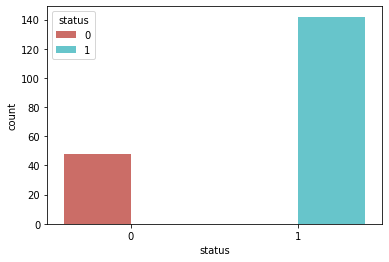

In [ ]:
"""
COME SONO DISTRIBUITI I SOGGETTI?
"""
if PLOT:
    sns.countplot(x='status',
                  hue = 'status',
                  data = pred_data,
                  palette='hls')

sample = (pred_data['status'] == 1).value_counts()
diff = sample[1] - sample[0]
print(f'SANI {sample[0]}')
print(f'MALATI {sample[1]}')
print(f'PER PAREGGIO: {diff}')

malati_eccesso = pred_data.loc[pred_data['status'] == 1]

delete_casual = malati_eccesso.sample(diff)

pred_data.drop(index=delete_casual.index, inplace=True)

def_sample = (pred_data['status'] == 1).value_counts()


SANI 48
MALATI 48


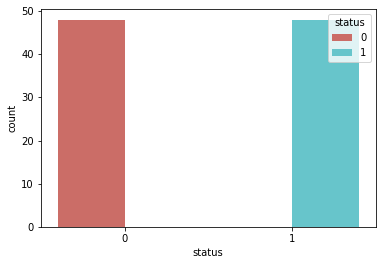

In [ ]:
print(f'SANI {def_sample[1]}')
print(f'MALATI {def_sample[0]}')

if PLOT:
    sns.countplot(x='status',
                  hue = 'status',
                  data = pred_data,
                  palette='hls')

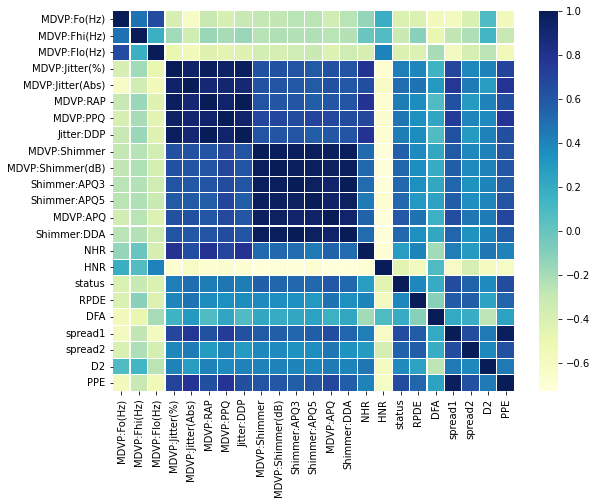

In [ ]:
"""
ANALISI STATISTICA DELLE FEATURES E RAPPORTI TRA LORO
"""

# USA IL PEARSON PER CREARE LA CORRELAZIONE
corrmat = pred_data.corr()

if PLOT:
    f, ax = plt.subplots(figsize =(9, 7))
    sns.heatmap(corrmat,
                annot= False,
                ax = ax,
                cmap ="YlGnBu",
                linewidths = 0.1)


In [ ]:
from sklearn.feature_selection import r_regression

reg = r_regression(pred_data, pred_data['status'])

prs = pd.DataFrame(data=reg, columns=['Pearson'], index= pred_data.columns.values)
prs.sort_values('Pearson',
                    ascending = False,
                    inplace = True)
prs.drop(labels='status', inplace = True)

prs

,Pearson
spread1,0.667941
PPE,0.655543
MDVP:APQ,0.600059
MDVP:Shimmer,0.556188
spread2,0.545585
MDVP:Shimmer(dB),0.539406
Shimmer:APQ5,0.524237
Shimmer:APQ3,0.520860
Shimmer:DDA,0.520819
MDVP:Jitter(Abs),0.500072


In [ ]:
pr_ft_np = pred_data.columns.values
pr_ft = list(pr_ft_np)
pr_ft
'status' in pr_ft

True

In [ ]:
if 'status' in pr_ft:
    print('status removed')
    pr_ft.remove('status')
else:
    print('clear')
'status' in pr_ft

status removed


False

In [ ]:
from sklearn.model_selection import train_test_split

# Isolo la classe output: STATUS 0 1, creo la Y
yp = pred_data[['status']].copy()

# Elimino l'output dalle features, credo la X
pred_data.drop(columns=["status"], inplace=True)
Xp = pred_data[pr_ft].copy()


In [ ]:
Xp.shape

(96, 22)

In [ ]:
"""
Eliminare eventuali FTRS molto simili
"""
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold()
selector.fit_transform(Xp)

Xp.shape

(96, 22)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(Xp,
                                                    yp,
                                                    random_state=0,
                                                    test_size=0.2)


print(f'DIM TRAIN TEST SPLIT:')
print(f'X_train = {X_train.shape} || X_test = {X_test.shape}')
print(f'y_train = {y_train.shape} || y_test = {y_test.shape}')


DIM TRAIN TEST SPLIT:
X_train = (76, 22) || X_test = (20, 22)
y_train = (76, 1) || y_test = (20, 1)


,Importance
MDVP:Fhi(Hz),0.274460
spread1,0.271376
PPE,0.252411
MDVP:APQ,0.248434
MDVP:Fo(Hz),0.229301


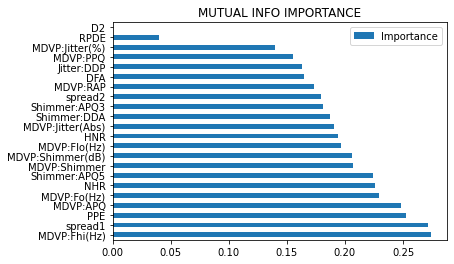

In [ ]:
from sklearn.feature_selection import mutual_info_classif

importance = mutual_info_classif(Xp, yp.values.ravel())

ft_import = pd.DataFrame(data=importance, columns=['Importance'])

ft_import.set_index(Xp.columns, inplace= True)

ft_import.sort_values('Importance',
                    ascending = False,
                    inplace = True)

ft_import.plot(kind='barh')
plt.title('MUTUAL INFO IMPORTANCE')
ft_import.head()


In [ ]:
"""
TEST CLASSIFICATORI
"""

from sklearn.ensemble import *
from sklearn.tree import *
from sklearn.svm import *
from sklearn.linear_model import *
from sklearn.metrics import *
from sklearn.model_selection import cross_val_score
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)

models = {'AdaBoostClassifier': AdaBoostClassifier,
         'ExtraTreesClassifier': ExtraTreesClassifier,
         'GradientBoostingClassifier': GradientBoostingClassifier,
         'RandomForestClassifier': RandomForestClassifier,
         'DecisionTreeClassifier': DecisionTreeClassifier,
         'ExtraTreeClassifier': ExtraTreeClassifier,
         'LinearSVC': LinearSVC,
         'NuSVC': NuSVC,
         'SVC': SVC,
         'RidgeClassifier': RidgeClassifier,
         'SGDClassifier': SGDClassifier}

In [ ]:
# print('CLASSIFIER TESTING: \n')

models_names = []
train_scores = []
test_scores = []
f1_sc = []
cr_sc_tr = []
cr_sc_ts = []
roc = []
conf_matrs = []

for name in models:
    model = models[name]
    # test_model(model, Xp, yp)
    model = model()
    model.fit(X_train, y_train.values.ravel())
    y_pred_tr = model.predict(X_train)
    y_pred_ts = model.predict(X_test)
    c_m = confusion_matrix(y_train, y_pred_tr)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    f1 = f1_score(y_train, y_pred_tr)
    roc_auc = roc_auc_score(y_train, y_pred_tr)
    cross_score_tr = cross_val_score(model,
                        X_train, y_train.values.ravel(),
                        cv=5, scoring='accuracy')
    cross_score_ts = cross_val_score(model,
                        X_test, y_test.values.ravel(),
                        cv=5, scoring='accuracy')
    # classification_report(y_train, y_pred)
    # print(f'{model}: \n TRAIN Score: {train_score*100} || TEST Score: {test_score*100}')
    models_names.append(name)
    train_scores.append(train_score)
    test_scores.append(test_score)
    f1_sc.append(f1)
    cr_sc_tr.append(cross_score_tr.mean())
    cr_sc_ts.append(cross_score_ts.mean())

    roc.append(roc_auc)
    conf_matrs.append(c_m)


In [ ]:
class_scores = pd.DataFrame(np.column_stack([train_scores,
                                             test_scores,f1_sc,roc, cr_sc_tr, cr_sc_ts]),
                               columns=['TR_sc', 'TS_sc', 'f1_sc', 'roc', 'cr_sc_tr', 'cr_sc_ts'],
                               index = models_names)

class_scores

,TR_sc,TS_sc,f1_sc,roc,cr_sc_tr,cr_sc_ts
AdaBoostClassifier,1.000000,0.90,1.000000,1.000000,0.819167,0.95
ExtraTreesClassifier,1.000000,1.00,1.000000,1.000000,0.869167,0.95
GradientBoostingClassifier,1.000000,0.90,1.000000,1.000000,0.843333,0.95
RandomForestClassifier,1.000000,0.90,1.000000,1.000000,0.818333,0.95
DecisionTreeClassifier,1.000000,0.95,1.000000,1.000000,0.710000,0.90
ExtraTreeClassifier,1.000000,0.85,1.000000,1.000000,0.778333,0.90
LinearSVC,0.526316,0.40,0.689655,0.500000,0.605000,0.55
NuSVC,0.789474,0.75,0.813953,0.784722,0.712500,0.80
SVC,0.697368,0.75,0.752688,0.687500,0.713333,0.50
RidgeClassifier,0.855263,0.80,0.867470,0.852778,0.790833,0.65


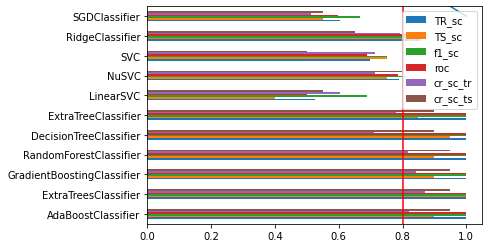

In [ ]:
# if PLOT:
class_scores.plot(kind ='barh')
x = 0.8
plt.plot((20,10))
plt.axvline(x, color='r') # vertical
plt.show()

In [ ]:
cm_srs = pd.Series(conf_matrs,index = models_names)
# cm_srs

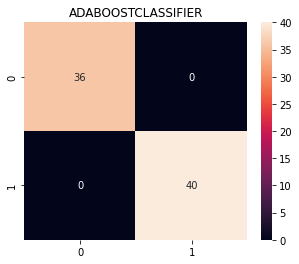

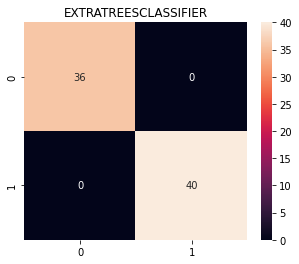

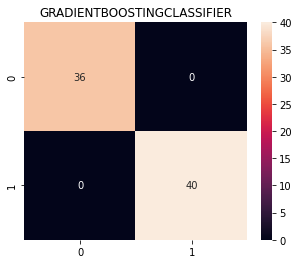

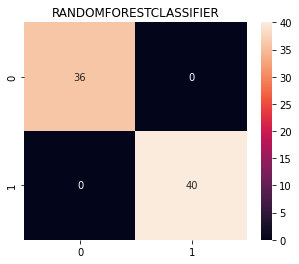

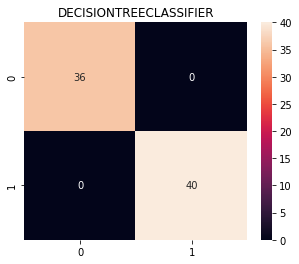

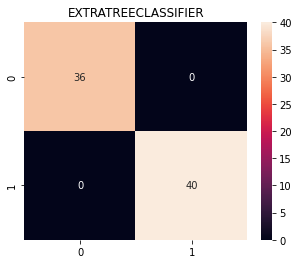

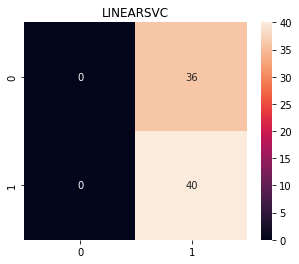

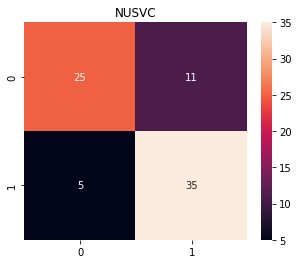

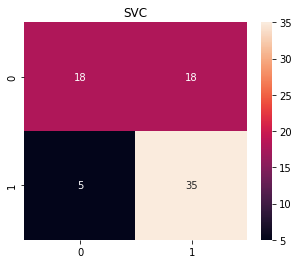

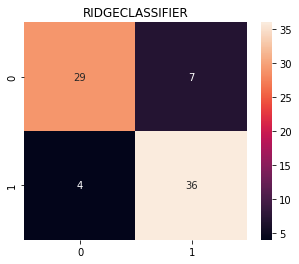

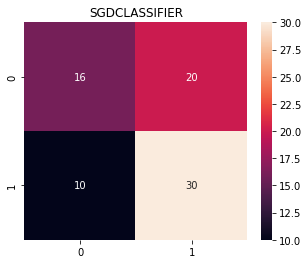

In [ ]:
n = 0
for cm in cm_srs:
    plt.figure(figsize=(5,4))
    plt.title(models_names[n].upper())
    sns.heatmap(cm, annot=True, cbar=True)
    n += 1

plt.show()

In [ ]:
"""
##############################################################################

SCELTA DEL CLASSIFICATORE PER FARE IMPORTANZA FEATURES

When combining multiple conditional statements, e
ach condition must be surrounded by parentheses ().
Moreover, you can not use or/and but need to use
the or operator | and the and operator &.

model_chose = class_scores[(class_scores["cr_sc"] > .8) & (class_scores["F1_ts"] > .8)]

##############################################################################

"""
score_chose = class_scores["cr_sc_tr"].max()

In [ ]:
mod = class_scores.loc[class_scores['cr_sc_tr'] == score_chose].index[0]
mod

'ExtraTreesClassifier'

,Coefficients
spread1,0.093857
PPE,0.089936
MDVP:Flo(Hz),0.065153
MDVP:Shimmer,0.063844
spread2,0.062252


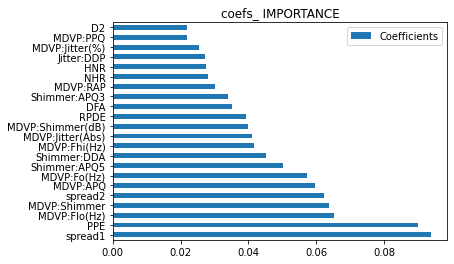

In [ ]:
model = eval(mod)() #rende callable una str
model.fit(X_train, y_train.values.ravel())

# if hasattr(model, 'feature_importances_'):
importances_mod_chose = model.feature_importances_

coefs_ = pd.DataFrame(
   np.transpose(importances_mod_chose),
   columns=['Coefficients'],
   index=X_train.columns)

coefs_.sort_values('Coefficients',
         ascending = False,
         inplace = True)

   # print(f'BEST 5 ftrs for {mod}: {coefs_.head()}')
# else:
#    print('No attribute *feature_importances_*')

coefs_.plot(kind='barh')
plt.title('coefs_ IMPORTANCE')
coefs_.head()

In [ ]:
ft_import.head()

,Importance
MDVP:Fhi(Hz),0.274460
spread1,0.271376
PPE,0.252411
MDVP:APQ,0.248434
MDVP:Fo(Hz),0.229301


In [ ]:
prs.head()

,Pearson
spread1,0.667941
PPE,0.655543
MDVP:APQ,0.600059
MDVP:Shimmer,0.556188
spread2,0.545585


In [ ]:
coefs_.head()

,Coefficients
spread1,0.093857
PPE,0.089936
MDVP:Flo(Hz),0.065153
MDVP:Shimmer,0.063844
spread2,0.062252


In [ ]:
"""
SCEGLIERE ED INSERIRLO IN 'PRIOR_CHOSE' : coefs_ , prs , ft_import
"""
PRIOR_CHOSE = prs
print(f'Priorità scelta: {PRIOR_CHOSE.head()}')
NUM = 10
FT = NUM

Priorità scelta:                Pearson
spread1       0.667941
PPE           0.655543
MDVP:APQ      0.600059
MDVP:Shimmer  0.556188
spread2       0.545585


In [ ]:
"""
FEATURES DA DARE IN PASTO ALLA
RETE NEURALE: LE PRIME FT = n SELEZIONATE DAI MODELLI
"""
ftrs_ANN_name = PRIOR_CHOSE.head(FT)
fts = ftrs_ANN_name.transpose()

ftrs_ANN = []
for l in fts.columns:
    if l != 'status':
        ftrs_ANN.append(l)

ftrs_ANN_tr = X_train[ftrs_ANN]
ftrs_ANN_ts = X_test[ftrs_ANN]

In [ ]:
name_select = ftrs_ANN_name.columns[0]
print(f'MODELLO: {name_select} || FEATURES SCELTE: {FT}')
for f in range(0,FT):
    print(f'{ftrs_ANN_tr.columns[f]}')

MODELLO: Pearson || FEATURES SCELTE: 10
spread1
PPE
MDVP:APQ
MDVP:Shimmer
spread2
MDVP:Shimmer(dB)
Shimmer:APQ5
Shimmer:APQ3
Shimmer:DDA
MDVP:Jitter(Abs)


In [ ]:
"""
VALORI SCALARI
"""

from sklearn.preprocessing import StandardScaler

StSc = StandardScaler()

StSc_tr = pd.DataFrame(StSc.fit_transform(ftrs_ANN_tr),
             columns=ftrs_ANN_tr.columns,
             index=ftrs_ANN_tr.index)

StSc_ts = pd.DataFrame(StSc.fit_transform(ftrs_ANN_ts),
             columns=ftrs_ANN_ts.columns,
             index=ftrs_ANN_ts.index)



In [ ]:
clfs = class_scores[['cr_sc_tr']].sort_values(by='cr_sc_tr',ascending=False)
classifiers = list(clfs.index[:2])
classifiers

['ExtraTreesClassifier', 'GradientBoostingClassifier']

Classification report for classifier ExtraTreesClassifier:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       1.00      0.88      0.93         8

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20


Classification report for classifier GradientBoostingClassifier:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        12
           1       0.88      0.88      0.88         8

    accuracy                           0.90        20
   macro avg       0.90      0.90      0.90        20
weighted avg       0.90      0.90      0.90        20




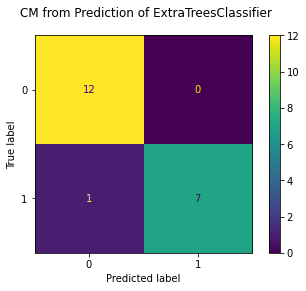

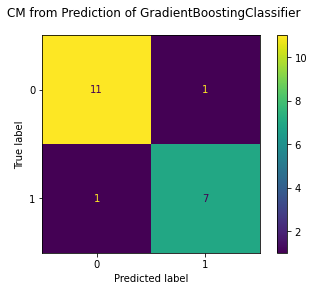

In [ ]:
for nm_clfs in classifiers:
    # print(nm_clfs)
    model = eval(nm_clfs)()
    model.fit(StSc_tr, y_train.values.ravel())
    predicted = model.predict(StSc_ts)
    print(
    f"Classification report for classifier {nm_clfs}:\n"
    f"{classification_report(y_test, predicted)}\n")
    cm_clf = ConfusionMatrixDisplay.from_predictions(y_test, predicted)
    cm_clf.figure_.suptitle(f'CM from Prediction of {nm_clfs}')


In [ ]:
BS = 22 # BATCH_SIZE: bacino di dati che viene dato alla ANN
VS = 0.2 # VAL_SPLIT
EPS = 100 # EPOCHS

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout

model = Sequential()
model.add(Dense(FT, activation='relu'))
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(1, activation='tanh'))


model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [ ]:
history = model.fit(StSc_tr, y_train,
                    epochs= EPS,
                    validation_data=(StSc_ts, y_test),
                    batch_size= BS,
                    verbose=False)

Train: 93.42105388641357, Test: 89.99999761581421


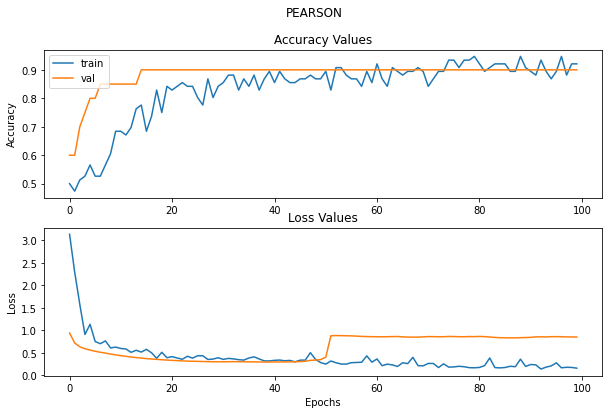

In [ ]:
_, train_acc = model.evaluate(StSc_tr, y_train, verbose=0)
_, test_acc = model.evaluate(StSc_ts, y_test, verbose=0)
print(f'Train: {train_acc*100}, Test: {test_acc*100}')

plt.figure(figsize = (10,6))
plt.suptitle(f'{str(name_select).upper()}')
plt.subplot(211)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title(f'Accuracy Values')
plt.ylabel('Accuracy')
plt.legend(['train', 'val'], loc='upper left')

plt.subplot(212)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss Values')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.show()


In [ ]:
"""
TEST COL NUOVO DATASET IGNOTO
"""
y_new = test_data['status']
test_data.drop(columns='status', inplace= True)
fts_chose = list(ftrs_ANN_tr.columns)

In [ ]:
X_new = test_data.copy()
X_sc = StSc.fit_transform(X_new)
X_new_sc = pd.DataFrame(StSc.fit_transform(X_sc),
             columns=X_new.columns,
             index=X_new.index)

X_new_sc[fts_chose]

,spread1,PPE,MDVP:APQ,MDVP:Shimmer,spread2,MDVP:Shimmer(dB),Shimmer:APQ5,Shimmer:APQ3,Shimmer:DDA,MDVP:Jitter(Abs)
82,1.175057,1.197370,-0.915823,-0.555054,-1.528642,-0.764037,-0.393931,-0.240479,-0.240076,1.372813
161,0.421383,0.372584,0.486189,0.213986,-0.285508,0.323170,0.012978,0.167290,0.167685,0.392232
159,-0.201415,-0.303969,0.692926,0.179443,-0.165725,0.462811,-0.084356,-0.256909,-0.257502,0.392232
84,0.404319,0.492558,1.174125,1.597530,1.535062,1.420352,1.770393,1.713225,1.713094,-0.588348
116,-1.799343,-1.758543,-1.437418,-1.435905,0.444813,-1.442295,-1.305083,-1.383127,-1.383201,-1.568929


In [ ]:
y_new2 = y_new.copy()
y_new2 = pd.DataFrame(y_new,
             columns=yp.columns)
y_new2.rename(columns={"status":"CONTROLLO"}, inplace = True)
# y_new2

In [ ]:
predictions = (model.predict(X_new_sc[fts_chose]) > 0.5).astype(int)
pred_ = pd.DataFrame(predictions,
             columns=yp.columns)
pred_.rename(columns={"status":"PRED. ANN"}, inplace = True)
# pred_

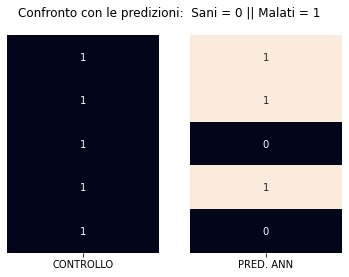

In [ ]:
fig, axs = plt.subplots(ncols=2,)
fig.suptitle(f'Confronto con le predizioni:  Sani = 0 || Malati = 1')
sns.heatmap(y_new2,
            annot=True, cbar=False,
            ax=axs[0],
            yticklabels=False)

sns.heatmap(pred_,
            annot=True, cbar=False,
            ax=axs[1],
            yticklabels=False)
plt.show()

In [ ]:
"""
CONFRONTO TRA I TRE CLASSIFICATORI
"""

clf1 = eval(classifiers[0])()
clf1.fit(StSc_tr, y_train.values.ravel())
predict_clf = (clf1.predict(X_new_sc[fts_chose]) > 0.5).astype(int)
pred_clf1 = pd.DataFrame(predict_clf, columns=yp.columns)
pred_clf1.rename(columns={"status":f"PRED. GBC"}, inplace = True)

clf2 = eval(classifiers[1])()
clf2.fit(StSc_tr, y_train.values.ravel())
predict_clf = (clf2.predict(X_new_sc[fts_chose]) > 0.5).astype(int)
pred_clf2 = pd.DataFrame(predict_clf, columns=yp.columns)
pred_clf2.rename(columns={"status":f"PRED. ETC"}, inplace = True)



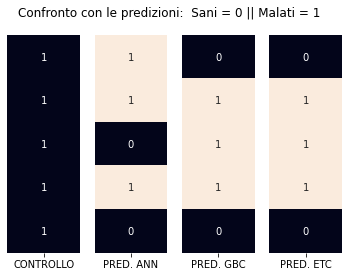

In [ ]:
y_new2

fig, axs = plt.subplots(ncols=4)
fig.suptitle(f'Confronto con le predizioni:  Sani = 0 || Malati = 1')
sns.heatmap(y_new2,
            annot=True, cbar=False,
            ax=axs[0],
            yticklabels=False)

sns.heatmap(pred_,
            annot=True, cbar=False,
            ax=axs[1],
            yticklabels=False)

sns.heatmap(pred_clf1,
            annot=True, cbar=False,
            ax=axs[2],
            yticklabels=False)

sns.heatmap(pred_clf2,
            annot=True, cbar=False,
            ax=axs[3],
            yticklabels=False)
plt.show()
